In [169]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.gridspec import GridSpec
import typing as t
data = pandas.read_csv("../report_int_v2.csv")
data["succeeded"] = data["succeeded"].astype(int)
data_per_sim = data.drop(columns="sim_id").groupby(['n_robots', 'algorithm', 'agent_id']).sum().reset_index()
avg_per_sim = data_per_sim.drop(columns="agent_id").groupby(['n_robots', 'algorithm']).mean()
std_per_sim = data_per_sim.drop(columns="agent_id").groupby(['n_robots', 'algorithm']).std()

data = data.drop(columns=["agent_id", "sim_id"])
success_rates = data.groupby(['n_robots','algorithm'])['succeeded'].mean().reset_index()

data_successes = data[data["succeeded"] == 1]

# data = data.drop(columns=["succeeded"])
# data_successes = data_successes.drop(columns=["succeeded"])


In [170]:
data

,n_robots,algorithm,succeeded,distance_traveled,n_transfers,planning_time,n_planning_timeouts,postponements,replans,transfer_distance_traveled,n_conflicts,n_rr_conflicts,n_steps
0,1,namo,1,913.685418,1.0,5.201267,0.0,0.0,1.0,201.213204,0.0,0.0,72.0
1,1,namo,1,74.999998,0.0,0.160019,0.0,0.0,1.0,0.000000,0.0,0.0,10.0
2,1,namo,1,1516.658554,2.0,6.302604,0.0,0.0,1.0,102.426409,0.0,0.0,120.0
3,1,namo,1,634.705627,0.0,0.391945,0.0,0.0,1.0,0.000000,0.0,0.0,48.0
4,1,namo,1,613.492424,0.0,0.457007,0.0,0.0,1.0,0.000000,0.0,0.0,47.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
242245,8,snamo_ncr,0,0.000000,0.0,0.928244,0.0,0.0,1.0,0.000000,1.0,1.0,1.0
242246,8,snamo_ncr,0,0.000000,0.0,0.309994,0.0,0.0,1.0,0.000000,1.0,1.0,1.0
242247,8,snamo_ncr,0,0.000000,0.0,7.849844,0.0,0.0,1.0,0.000000,1.0,1.0,1.0
242248,8,snamo_ncr,0,0.000000,0.0,18.070113,0.0,0.0,1.0,0.000000,1.0,1.0,1.0


In [171]:
avg_per_sim

succeeded  distance_traveled  n_transfers  planning_time  \
n_robots algorithm                                                              
1        namo       968.000000       7.209958e+05   464.000000    2435.400622   
         namo_ncr   968.000000       7.209958e+05   464.000000    2434.986155   
         namo_ndr   968.000000       7.209958e+05   464.000000    2437.928218   
         snamo      983.000000       6.199368e+05   398.000000    4287.207961   
         snamo_ncr  983.000000       6.199368e+05   398.000000    4283.330176   
         snamo_ndr  983.000000       6.199368e+05   398.000000    4266.244381   
2        namo       933.000000       9.599493e+05   518.500000    7285.516836   
         namo_ncr   459.500000       3.117635e+05   218.500000    2080.124236   
         namo_ndr   757.000000       5.455128e+05   369.000000    4529.607237   
         snamo      876.500000       6.145828e+05   343.000000   11490.144747   
         snamo_ncr  419.500000       2.512343e+05   172.000000    7576.260486   
         snamo_ndr  756.500000       5.006555e+05   319.000000   10115.818781   
3        namo       838.333333       1.017386e+06   462.666667   10204.413562   
         namo_ncr   261.000000       1.682140e+05   118.666667    2436.350492   
         namo_ndr   572.000000       4.641059e+05   318.333333    6076.945776   
         snamo      860.666667       7.212528e+05   344.666667   16173.363151   
         snamo_ncr  302.333333       1.794095e+05   115.333333    9215.406458   
         snamo_ndr  615.333333       4.472862e+05   261.666667   13357.647233   
4        namo       774.500000       1.053890e+06   430.750000   14507.933061   
         namo_ncr   217.500000       1.275127e+05    96.000000    2126.368815   
         namo_ndr   463.500000       3.744272e+05   245.750000    7038.908881   
         snamo      728.250000       6.712072e+05   276.750000   18929.790316   
         snamo_ncr  204.000000       1.189823e+05    79.500000    8601.727783   
         snamo_ndr  475.750000       3.472266e+05   190.000000   14627.473162   
5        namo       699.600000       1.188935e+06   363.400000   16880.321826   
         namo_ncr   172.000000       9.849048e+04    74.400000    2237.975982   
         namo_ndr   352.200000       3.450535e+05   192.200000    7097.150667   
         snamo      684.600000       7.775727e+05   258.400000   25435.776305   
         snamo_ncr  154.000000       8.698891e+04    59.600000    9211.679267   
         snamo_ndr  374.400000       3.020699e+05   147.200000   16654.740489   
6        namo       642.666667       1.154655e+06   335.166667   21226.869475   
         namo_ncr   134.500000       7.031996e+04    59.166667    2248.886586   
         namo_ndr   304.333333       2.831362e+05   156.833333    7384.178765   
         snamo      620.500000       7.698832e+05   227.833333   26913.714453   
         snamo_ncr  126.666667       6.733984e+04    44.500000    8324.495036   
         snamo_ndr  296.666667       2.352847e+05   112.333333   18099.027615   
7        namo       503.428571       1.028585e+06   265.285714   21169.778453   
         namo_ncr   104.857143       5.729155e+04    50.428571    2439.827185   
         namo_ndr   200.142857       1.943475e+05   116.428571    7681.432629   
         snamo      489.000000       6.909281e+05   184.142857   29223.956327   
         snamo_ncr  106.000000       5.466160e+04    39.000000    9532.313932   
         snamo_ndr  219.428571       1.769649e+05    93.000000   20084.015884   
8        namo       469.500000       9.289243e+05   232.750000   22399.524676   
         namo_ncr    95.375000       4.693201e+04    38.750000    2179.983071   
         namo_ndr   171.875000       1.781508e+05    90.875000    7101.214603   
         snamo      443.000000       6.878424e+05   163.625000   34284.724901   
         snamo_ncr   88.625000       4.699264e+04    33.750000    9279.826316   
         snamo_ndr  178.625000       1.606603e+05   

In [172]:
avg_per_sim.reset_index()[['n_robots', 'algorithm', 'succeeded']]

,n_robots,algorithm,succeeded
0,1,namo,968.000000
1,1,namo_ncr,968.000000
2,1,namo_ndr,968.000000
3,1,snamo,983.000000
4,1,snamo_ncr,983.000000
5,1,snamo_ndr,983.000000
6,2,namo,933.000000
7,2,namo_ncr,459.500000
8,2,namo_ndr,757.000000
9,2,snamo,876.500000


In [173]:
std_per_sim.reset_index()[['n_robots', 'algorithm', 'succeeded']]

,n_robots,algorithm,succeeded
0,1,namo,NaN
1,1,namo_ncr,NaN
2,1,namo_ndr,NaN
3,1,snamo,NaN
4,1,snamo_ncr,NaN
5,1,snamo_ndr,NaN
6,2,namo,11.313708
7,2,namo_ncr,24.748737
8,2,namo_ndr,8.485281
9,2,snamo,10.606602


In [174]:
data_successes

,n_robots,algorithm,succeeded,distance_traveled,n_transfers,planning_time,n_planning_timeouts,postponements,replans,transfer_distance_traveled,n_conflicts,n_rr_conflicts,n_steps
0,1,namo,1,913.685418,1.0,5.201267,0.0,0.0,1.0,201.213204,0.0,0.0,72.0
1,1,namo,1,74.999998,0.0,0.160019,0.0,0.0,1.0,0.000000,0.0,0.0,10.0
2,1,namo,1,1516.658554,2.0,6.302604,0.0,0.0,1.0,102.426409,0.0,0.0,120.0
3,1,namo,1,634.705627,0.0,0.391945,0.0,0.0,1.0,0.000000,0.0,0.0,48.0
4,1,namo,1,613.492424,0.0,0.457007,0.0,0.0,1.0,0.000000,0.0,0.0,47.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
242048,8,snamo_ncr,1,36.213203,0.0,0.170346,0.0,0.0,1.0,0.000000,0.0,0.0,7.0
242049,8,snamo_ncr,1,45.000000,0.0,0.146438,0.0,0.0,1.0,0.000000,0.0,0.0,6.0
242100,8,snamo_ncr,1,967.953949,2.0,28.224409,0.0,0.0,1.0,237.426409,0.0,0.0,82.0
242109,8,snamo_ncr,1,78.639610,0.0,0.465828,0.0,0.0,1.0,0.000000,0.0,0.0,9.0


In [175]:
success_rates

,n_robots,algorithm,succeeded
0,1,namo,0.968000
1,1,namo_ncr,0.968000
2,1,namo_ndr,0.968000
3,1,snamo,0.983000
4,1,snamo_ncr,0.983000
5,1,snamo_ndr,0.983000
6,2,namo,0.933000
7,2,namo_ncr,0.459500
8,2,namo_ndr,0.757000
9,2,snamo,0.876500


In [176]:
avg = data.groupby(['n_robots', 'algorithm']).mean()
avg_success = data_successes.groupby(['n_robots','algorithm']).mean()

In [177]:
avg

succeeded  distance_traveled  n_transfers  planning_time  \
n_robots algorithm                                                             
1        namo        0.968000         720.995833     0.464000       2.435401   
         namo_ncr    0.968000         720.995833     0.464000       2.434986   
         namo_ndr    0.968000         720.995833     0.464000       2.437928   
         snamo       0.983000         619.936806     0.398000       4.287208   
         snamo_ncr   0.983000         619.936806     0.398000       4.283330   
         snamo_ndr   0.983000         619.936806     0.398000       4.266244   
2        namo        0.933000         959.949301     0.518500       7.285517   
         namo_ncr    0.459500         311.763520     0.218500       2.080124   
         namo_ndr    0.757000         545.512799     0.369000       4.529607   
         snamo       0.876500         614.582768     0.343000      11.490145   
         snamo_ncr   0.419500         251.234323     0.172000       7.576260   
         snamo_ndr   0.756500         500.655469     0.319000      10.115819   
3        namo        0.838333        1017.386340     0.462667      10.204414   
         namo_ncr    0.261000         168.213983     0.118667       2.436350   
         namo_ndr    0.572000         464.105895     0.318333       6.076946   
         snamo       0.860667         721.252843     0.344667      16.173363   
         snamo_ncr   0.302333         179.409456     0.115333       9.215406   
         snamo_ndr   0.615333         447.286169     0.261667      13.357647   
4        namo        0.774500        1053.890032     0.430750      14.507933   
         namo_ncr    0.217500         127.512672     0.096000       2.126369   
         namo_ndr    0.463500         374.427173     0.245750       7.038909   
         snamo       0.728250         671.207222     0.276750      18.929790   
         snamo_ncr   0.204000         118.982306     0.079500       8.601728   
         snamo_ndr   0.475750         347.226581     0.190000      14.627473   
5        namo        0.699600        1188.935428     0.363400      16.880322   
         namo_ncr    0.172000          98.490477     0.074400       2.237976   
         namo_ndr    0.352200         345.053509     0.192200       7.097151   
         snamo       0.684600         777.572714     0.258400      25.435776   
         snamo_ncr   0.154000          86.988908     0.059600       9.211679   
         snamo_ndr   0.374400         302.069887     0.147200      16.654740   
6        namo        0.642667        1154.655030     0.335167      21.226869   
         namo_ncr    0.134500          70.319957     0.059167       2.248887   
         namo_ndr    0.304333         283.136190     0.156833       7.384179   
         snamo       0.620500         769.883246     0.227833      26.913714   
         snamo_ncr   0.126667          67.339842     0.044500       8.324495   
         snamo_ndr   0.296667         235.284749     0.112333      18.099028   
7        namo        0.529925        1082.721108     0.279248      22.283977   
         namo_ncr    0.104857          57.291547     0.050429       2.439827   
         namo_ndr    0.200143         194.347538     0.116429       7.681433   
         snamo       0.489000         690.928077     0.184143      29.223956   
         snamo_ncr   0.106000          54.661600     0.039000       9.532314   
         snamo_ndr   0.219429         176.964865     0.093000      20.084016   
8        namo        0.494211         977.815061     0.245000      23.578447   
         namo_ncr    0.095375          46.932005     0.038750       2.179983   
         namo_ndr    0.171875         178.150788     0.090875       7.101215   
         snamo       0.443000         687.842411     0.163625      34.284725   
         snamo_ncr   0.088625          46.992644     0.033750       9.279826   
         snamo_ndr   0.178625         160.660262     0.074625      17.970154   
9        namo       

In [178]:
std = data.groupby(['n_robots','algorithm']).std()
std_success = data_successes.groupby(['n_robots','algorithm']).std()
std

succeeded  distance_traveled  n_transfers  planning_time  \
n_robots algorithm                                                             
1        namo        0.176088         743.725196     0.602550       4.121163   
         namo_ncr    0.176088         743.725196     0.602550       4.084205   
         namo_ndr    0.176088         743.725196     0.602550       4.115572   
         snamo       0.129336         533.930307     0.543959      12.114792   
         snamo_ncr   0.129336         533.930307     0.543959      12.007487   
         snamo_ndr   0.129336         533.930307     0.543959      12.131282   
2        namo        0.250085        2200.978575     0.717576      32.889400   
         namo_ncr    0.498482         457.132222     0.477359       3.242484   
         namo_ndr    0.429002         657.746771     0.621315      14.916593   
         snamo       0.329093         755.273495     0.571414      36.792071   
         snamo_ncr   0.493601         392.561013     0.430707      17.952031   
         snamo_ndr   0.429302         573.769345     0.569562      30.259019   
3        namo        0.368206        1907.669467     0.702925      23.296876   
         namo_ncr    0.439253         316.597906     0.361426       3.355270   
         namo_ndr    0.494871         641.978973     0.597034      13.749041   
         snamo       0.346352         960.548838     0.583082      45.656630   
         snamo_ncr   0.459345         332.860355     0.363422      17.627007   
         snamo_ndr   0.486598         575.380147     0.532251      38.196385   
4        namo        0.417963        1990.829015     0.684340      29.756422   
         namo_ncr    0.412597         261.009378     0.319076       2.937242   
         namo_ndr    0.498728         583.373161     0.550393      17.122168   
         snamo       0.444917         997.754704     0.531253      49.823824   
         snamo_ncr   0.403019         257.230592     0.292748      16.556972   
         snamo_ndr   0.499474         511.835606     0.459296      41.181767   
5        namo        0.458478        2208.170379     0.631364      32.744517   
         namo_ncr    0.377418         207.978542     0.278712       4.514266   
         namo_ndr    0.477704         587.187839     0.479276      14.443315   
         snamo       0.464721        1151.733844     0.520080      57.097968   
         snamo_ncr   0.360985         202.186095     0.255462      16.239851   
         snamo_ndr   0.484016         484.534311     0.405913      44.339044   
6        namo        0.479254        1930.107238     0.606815      36.720696   
         namo_ncr    0.341217         178.145832     0.248347       2.708897   
         namo_ndr    0.460163         501.491041     0.442270      14.003550   
         snamo       0.485303        1108.445953     0.487475      59.923726   
         snamo_ncr   0.332627         176.746061     0.216474      15.937695   
         snamo_ndr   0.456826         424.344116     0.365244      42.677515   
7        namo        0.499141        1748.505447     0.570551      36.106649   
         namo_ncr    0.306391         147.014084     0.231533       2.925932   
         namo_ndr    0.400136         386.114585     0.378768      16.889543   
         snamo       0.499915        1106.097325     0.454791      62.914869   
         snamo_ncr   0.307860         150.082733     0.204379      17.613567   
         snamo_ndr   0.413889         364.073603     0.339868      45.663939   
8        namo        0.499999        1448.714039     0.530651      31.378185   
         namo_ncr    0.293751         128.883503     0.200009       2.909855   
         namo_ndr    0.377295         358.952961     0.339310      13.340502   
         snamo       0.496771         995.888209     0.422935      69.114636   
         snamo_ncr   0.284219         143.188935     0.184703      16.829146   
         snamo_ndr   0.383062         347.826278     0.296339      41.632659   
9        namo       

In [179]:
goal_success_rates_avg = avg["succeeded"]
dist_per_success_avg = avg_success["distance_traveled"]
dist_per_success_std = std_success["distance_traveled"]

In [180]:
dist_per_success_avg

n_robots  algorithm
1         namo         744.830406
          namo_ncr     744.830406
          namo_ndr     744.830406
          snamo        630.657992
          snamo_ncr    630.657992
          snamo_ndr    630.657992
2         namo         745.287855
          namo_ncr     505.742312
          namo_ndr     626.799842
          snamo        644.969346
          snamo_ncr    466.574029
          snamo_ndr    596.657298
3         namo         827.416483
          namo_ncr     404.539824
          namo_ndr     629.056119
          snamo        677.914637
          snamo_ncr    410.813956
          snamo_ndr    581.378862
4         namo         826.710233
          namo_ncr     339.984635
          namo_ndr     538.650025
          snamo        669.605241
          snamo_ncr    358.990935
          snamo_ndr    516.292083
5         namo         820.344282
          namo_ncr     294.818021
          namo_ndr     546.193196
          snamo        661.938919
          snamo_ncr    306.6

In [181]:
std.loc[[(1,"namo"), (1, "snamo")]]

succeeded  distance_traveled  n_transfers  planning_time  \
n_robots algorithm                                                             
1        namo        0.176088         743.725196     0.602550       4.121163   
         snamo       0.129336         533.930307     0.543959      12.114792   

                    n_planning_timeouts  postponements  replans  \
n_robots algorithm                                                
1        namo                       0.0            0.0      0.0   
         snamo                      0.0            0.0      0.0   

                    transfer_distance_traveled  n_conflicts  n_rr_conflicts  \
n_robots algorithm                                                            
1        namo                        56.560397          0.0             0.0   
         snamo                      136.725527          0.0             0.0   

                      n_steps  
n_robots algorithm             
1        namo       54.653435  
         snamo      39.704838

In [182]:
max_robots = 8
algs = {
    "namo": "NAMO",
    "namo_ndr": "NAMO w/o Deadlock Resolution",
    "namo_ncr": "NAMO w/o Conflict Resolution",
    "snamo": "SNAMO",
    "snamo_ndr": "SNAMO w/o Deadlock Resolution",
    "snamo_ncr": "SNAMO w/o Conflict Resolution",
}

In [183]:
def plot_metric_by_num_robots(
    *,
    ax: Axes,
    algs: t.Dict[str, str],
    max_robots: int,
    avg,
    std,
    ylabel: str,
    show_legend: bool = False,
    show_std: bool = False
):
    fig_legend = plt.figure("Legend")

    lines = []
    labels = []
    for alg, title in algs.items():
        means = np.array([avg.loc[(i, alg)] for i in range(1, max_robots + 1)])
        stds = np.array([std.loc[(i, alg)] for i in range(1, max_robots + 1)])
        (line,) = ax.plot(
            range(1, max_robots + 1),
            means,
            label=title,
        )
        lines.append(line)
        labels.append(title)
        if show_std:
            ax.fill_between(
                x=range(1, max_robots + 1),
                y1=means - stds,
                y2=means + stds,
                alpha=0.2,
            )
    fig_legend.legend(lines, labels, loc='center')
    fig_legend.savefig('intersections_legend.png', bbox_inches='tight')
    # ax.set_ylabel(ylabel)
    ax.set_xlim([1, max_robots])

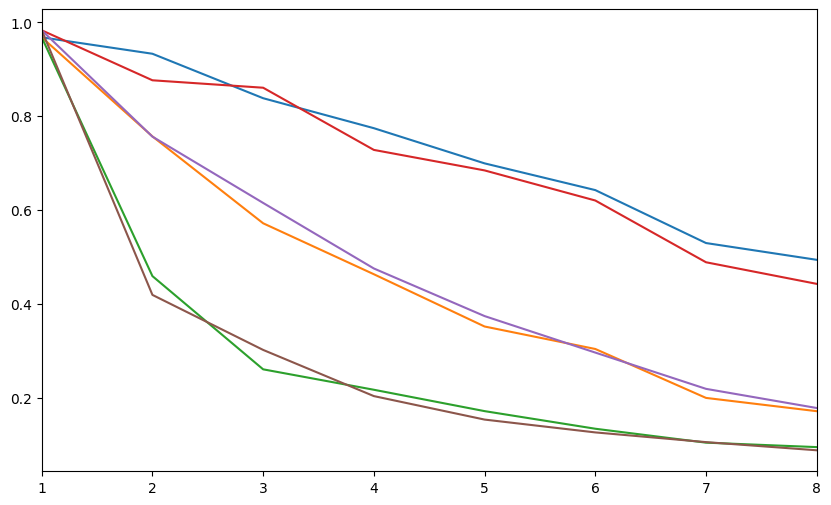

<Figure size 640x480 with 0 Axes>

In [184]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['succeeded'],
    std=std['succeeded'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Goal Success Rate",
)
fig.savefig('intersections_goal_success_rates.png', bbox_inches='tight')

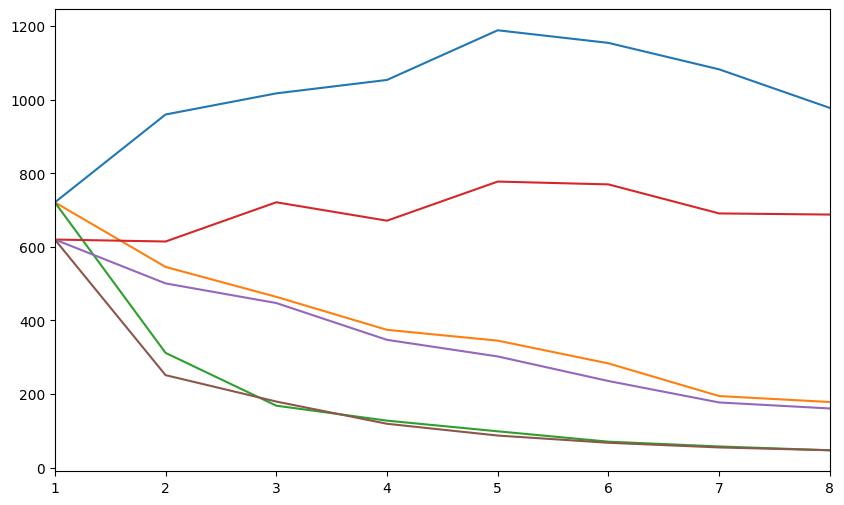

<Figure size 640x480 with 0 Axes>

In [185]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['distance_traveled'],
    std=std['distance_traveled'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Distance",
)
fig.savefig('intersections_avg_distance_traveled.png', bbox_inches='tight')

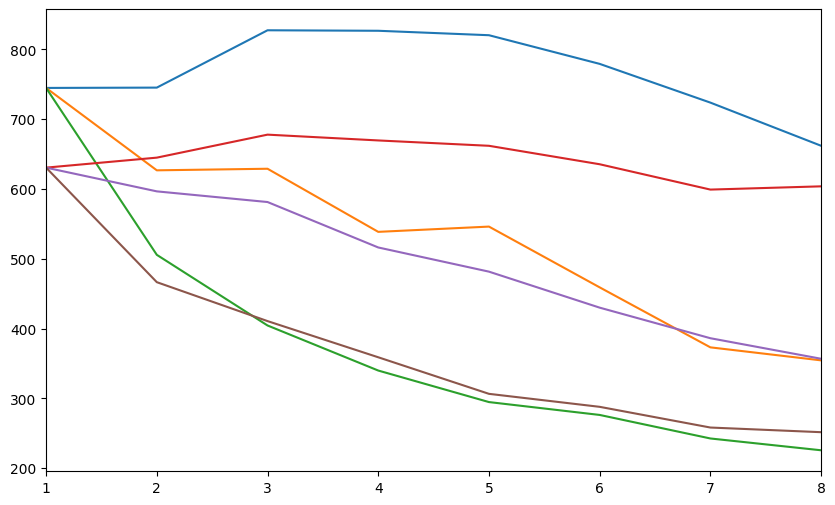

<Figure size 640x480 with 0 Axes>

In [186]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=dist_per_success_avg,
    std=dist_per_success_std,
    max_robots=max_robots,
    algs=algs,
    ylabel="Distance Per Successful Goal",
)
fig.savefig('intersections_avg_distance_traveled_per_success.png', bbox_inches='tight')

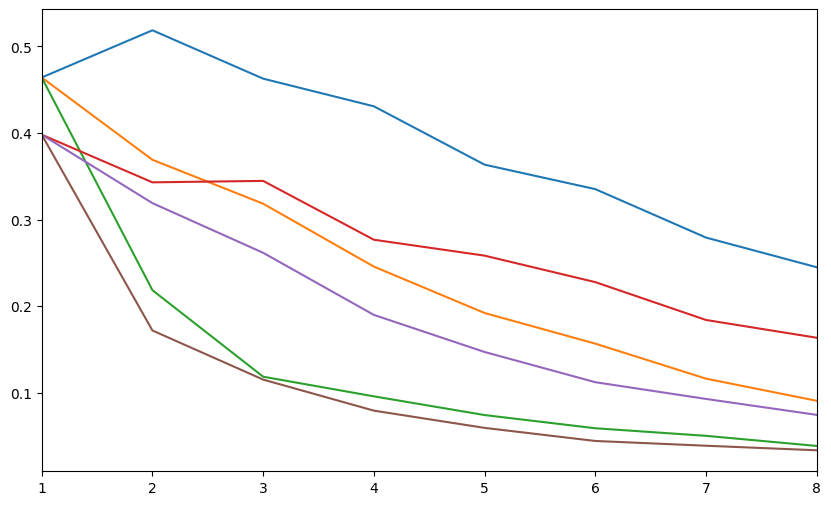

<Figure size 640x480 with 0 Axes>

In [187]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['n_transfers'],
    std=std['n_transfers'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Num Transfers",
)
fig.savefig('intersections_num_transfers.png', bbox_inches='tight')

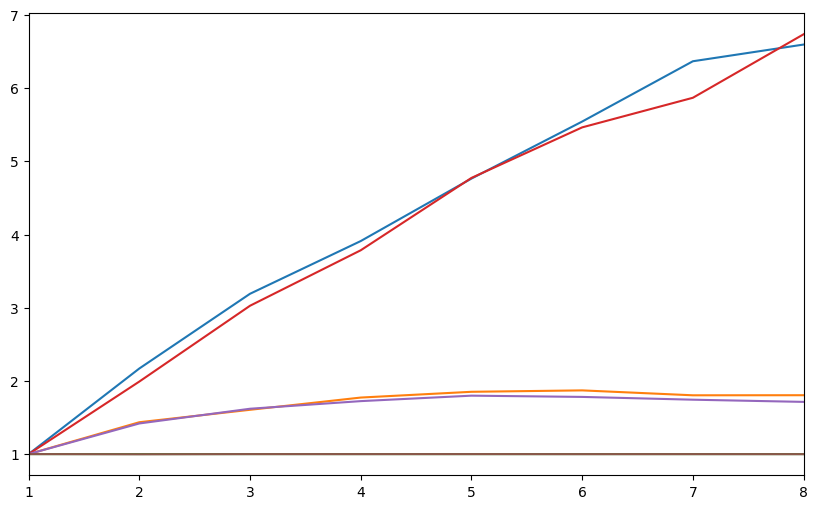

<Figure size 640x480 with 0 Axes>

In [188]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['replans'],
    std=std['replans'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Num Replans",
)
fig.savefig('intersections_num_replans.png', bbox_inches='tight')

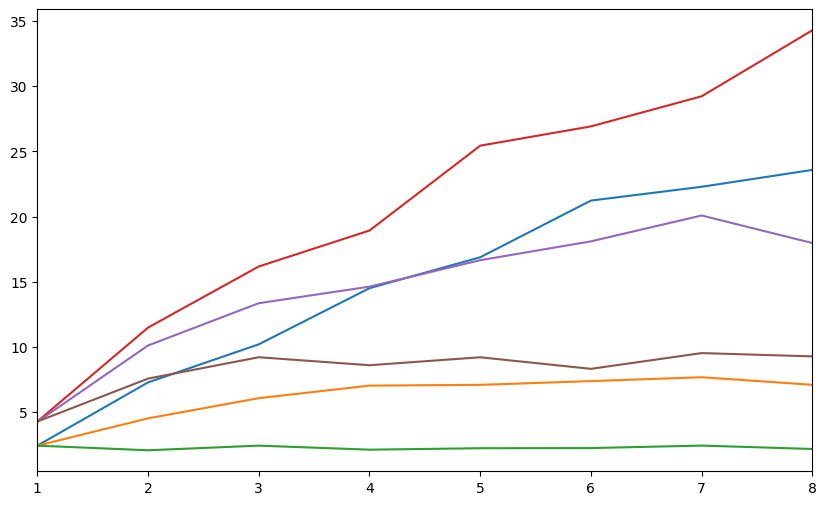

<Figure size 640x480 with 0 Axes>

In [189]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['planning_time'],
    std=std['planning_time'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Planning Time",
)
fig.savefig('intersections_planning_time.png', bbox_inches='tight')

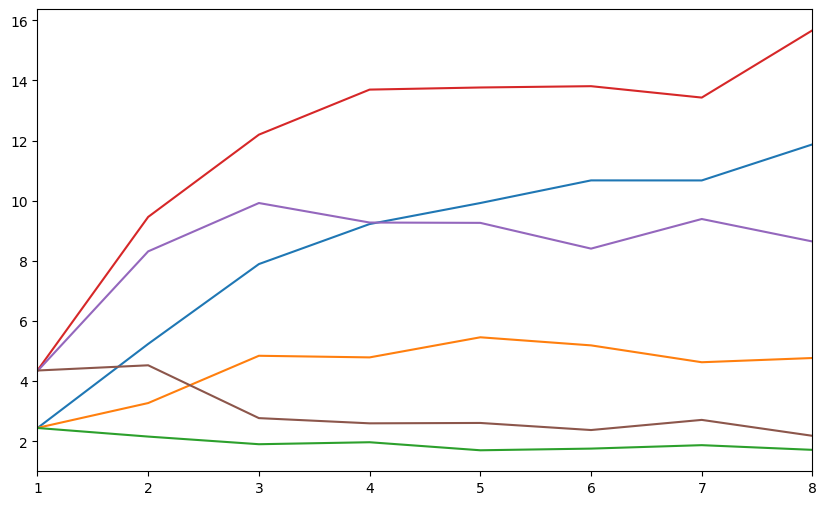

<Figure size 640x480 with 0 Axes>

In [190]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_success['planning_time'],
    std=avg_success['planning_time'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Planning Time",
)
fig.savefig('intersections_goal_planning_time_per_success.png', bbox_inches='tight')

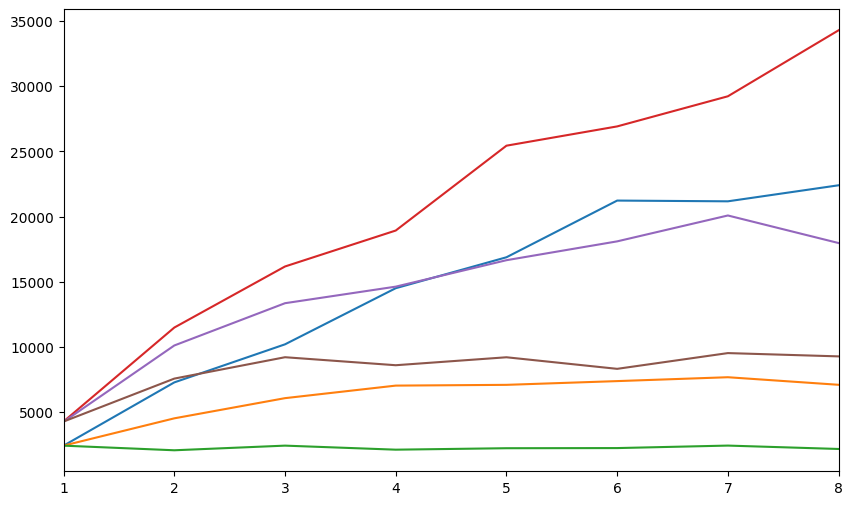

<Figure size 640x480 with 0 Axes>

In [191]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_sim['planning_time'],
    std=std_per_sim['planning_time'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Planning Time",
)
fig.savefig('intersections_sim_planning_time.png', bbox_inches='tight')

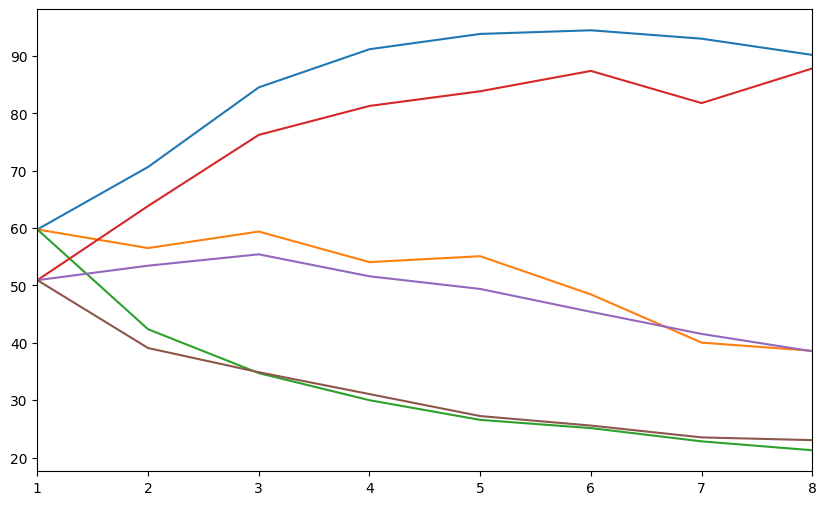

<Figure size 640x480 with 0 Axes>

In [192]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_success['n_steps'],
    std=std_success['n_steps'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Steps",
)
fig.savefig('intersections_steps.png', bbox_inches='tight')

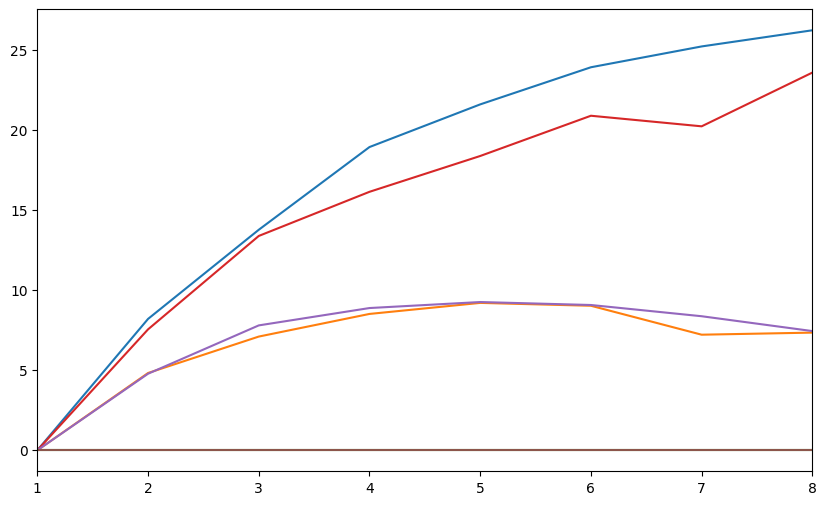

<Figure size 640x480 with 0 Axes>

In [193]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_success['postponements'],
    std=std_success['postponements'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Postponments",
)
fig.savefig('intersections_postpones.png', bbox_inches='tight')